# Data Visualizations

In [ ]:
# import packages 
import numpy as np
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib.dates as mdates
import plotly.graph_objects as go

In [418]:
# colors 

'#f5f0e8'   # body-bg, hero bg, conclusion text, back-btn hover area
'#1a1a1a'   # body-color, hero h1, narrative-block text, conclusion bg, picker-btn active border
'#320b8d'   # link-color, kicker, artist-a accent, border-left on narrative-block, back-btn text
'#06395b'   # artist-b accent
'#4f0335'   # artist-c accent
'#252525'   # conclusion type-card background

color1 = ['#320b8d', '#6b46c8', "#cab6fd", 'rgba(50, 11, 141, 0.3)', 'rgba(107, 70, 200, 0.3)' ]
color2 = ['#06395b', "#458dbd", "#adddfc", 'rgba(6, 57, 91, 0.3)', 'rgba(69, 141, 189, 0.3)' ]
color3 = ['#4f0335', '#882a9d', '#e4d1ee', 'rgba(79, 3, 52, 0.3)', 'rgba(136, 42, 157, 0.3)' ]
color4 = ['#6b2d0f', '#bd6220', "#f4c7a7", 'rgba(107, 45, 15, 0.3)', 'rgba(189, 98, 32, 0.3)' ]
color5 = ['#1a5c3a', "#4f916f", "#b4d9c6", 'rgba(79, 145, 111, 0.3)', 'rgba(180, 217, 198, 0.3)' ]

In [3]:
# theme 
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "none",
        "axes.facecolor": "none",
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 20
    }
)

font_manager.fontManager.addfont("PlayfairDisplay-VariableFont_wght.ttf")
plt.rcParams["font.family"] = "Playfair Display"

In [4]:
# load data 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)

## Number of Songs per Artist

In [5]:
# get unique songs
df_artist = df.copy()
df_artist = df_artist.groupby(by=['title','artist','artist_list']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()

# explode artist list to make one obs per artist 
df_artist['artist_list'] = df_artist['artist_list'].apply(ast.literal_eval)
df_artist = df_artist.explode('artist_list')

# count number of songs 
num_songs_per_artist = df_artist.groupby(by=['artist_list']).agg(num_songs = ('title','count')).reset_index()
num_songs_per_artist = num_songs_per_artist.sort_values('num_songs', ascending=False)

In [28]:
num_songs_per_artist.head(20)

,artist_list,num_songs
380,Drake,266
1264,Taylor Swift,211
484,Future,196
788,Lil Baby,157
1337,Travis Scott,127
116,Bad Bunny,113
802,Lil Uzi Vert,113
5,21 Savage,111
936,Morgan Wallen,106
1430,YoungBoy Never Broke Again,104


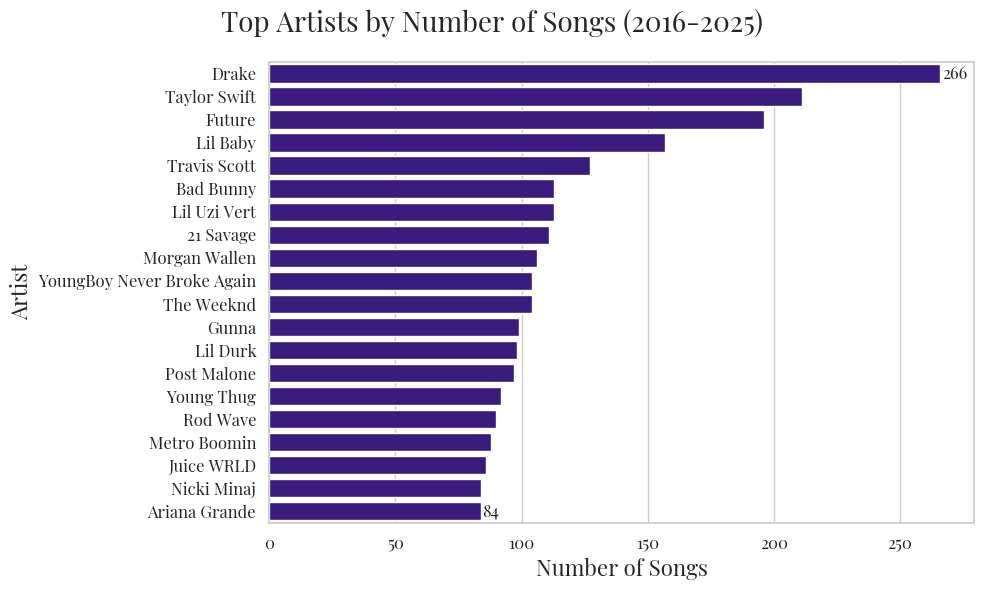

In [6]:
# keep top N artists
top_n = 20
artist_counts = num_songs_per_artist.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=artist_counts, x='num_songs', y='artist_list', color='#320b8d')

max_idx = 0
min_idx = 19

for i, row in artist_counts.iterrows():
    if i == max_idx or i == min_idx:
        ax.text(
            row['num_songs'] + 0.5,
            artist_counts.index.get_loc(i),
            str(row['num_songs']),
            va='center'
        )

plt.xlabel('Number of Songs')
plt.ylabel('Artist')
plt.suptitle("Top Artists by Number of Songs (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_songs_per_artist.svg', format='svg')

plt.show()

## Max Number of Weeks on Chart per Song

In [7]:
# get unique songs
df_songs = df.copy()
df_songs = df_songs.groupby(by=['title','artist']).agg(weeks_in_data = ('chart_date','count'), max_weeks_on_chart = ('weeks_on_chart', 'max')).reset_index()
num_weeks_per_song = df_songs.sort_values(by=['weeks_in_data'], ascending=False)

In [62]:
num_weeks_per_song.head(20)

,title,artist,weeks_in_data,max_weeks_on_chart
2984,Lose Control,Teddy Swims,112,112
2134,Heat Waves,Glass Animals,91,91
621,Blinding Lights,The Weeknd,90,90
487,Beautiful Things,Benson Boone,89,89
123,A Bar Song (Tipsy),Shaboozey,77,77
2869,Levitating,Dua Lipa,77,77
5649,Wildflower,Billie Eilish,72,72
4561,Snooze,SZA,70,70
4337,Save Your Tears,The Weeknd & Ariana Grande,69,69
3924,Pink Pony Club,Chappell Roan,68,68


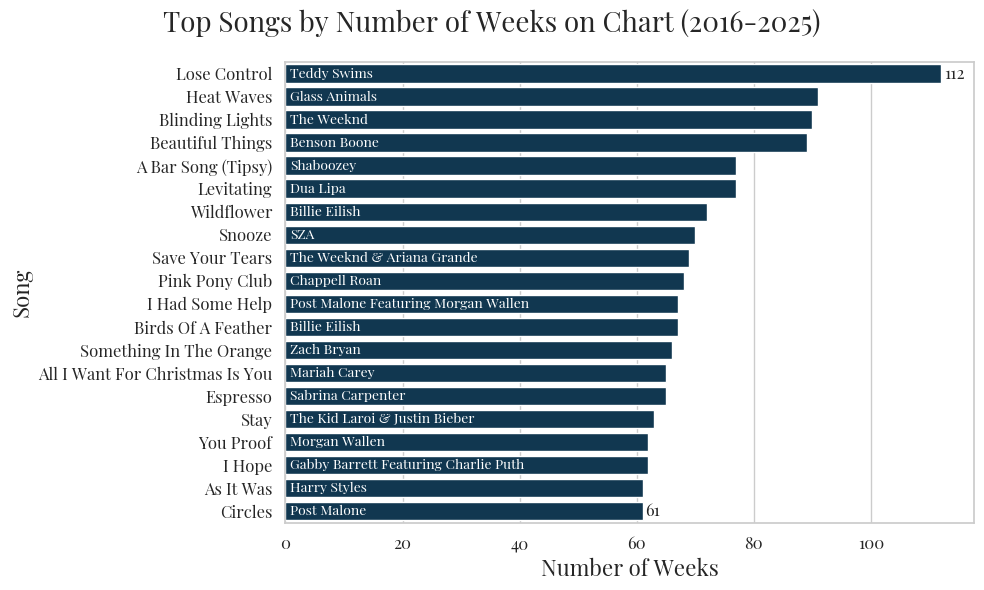

In [8]:
# keep top N songs
top_n = 20
song_counts = num_weeks_per_song.head(top_n).reset_index(drop=True)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=song_counts, x='weeks_in_data', y='title', color='#06395b')

max_idx = 0
min_idx = 19

for i, row in song_counts.iterrows():
    ax.text(
        0.75,
        song_counts.index.get_loc(i),
        str(row['artist']),
        va='center',
        color='white',
        size=10
    )
    if i == max_idx or i == min_idx:
        ax.text(
            row['weeks_in_data'] + 0.5,
            song_counts.index.get_loc(i),
            str(row['weeks_in_data']),
            va='center'
        )

plt.xlabel('Number of Weeks')
plt.ylabel('Song')
plt.suptitle("Top Songs by Number of Weeks on Chart (2016-2025)", fontsize=20)
plt.tight_layout()

# save 
plt.savefig('../charts/num_weeks_per_song.svg', format='svg')

plt.show()

## Fill in weeks off chart with NA

In [185]:
# fill in middle off chart weeks for each song 
df = pd.read_csv("../data/clean_hot100_history.csv", low_memory=False)
songs = df[['title', 'artist', 'artist_list']].drop_duplicates()

In [186]:
def fill_song(group):

    group = group.sort_values("chart_date")

    full_range = pd.date_range(
        start=group["chart_date"].min(),
        end=group["chart_date"].max(),
        freq="W-SAT"
    )
    new_rows = pd.DataFrame(data = {
        'chart_date': full_range,
        'title': group["title"].iloc[0],
        'artist': group["artist"].iloc[0],
        'artist_list': group["artist_list"].iloc[0],
    })
    if new_rows.shape[0] != group.shape[0]:
        new_group = new_rows.merge(group, how='left')
        return new_group 
    else:
        return group

df["chart_date"] = pd.to_datetime(df["chart_date"])
dfs = []
for row in songs.iterrows():
    mask = (df['title']==str(row[1]['title']))&(df['artist']==str(row[1]['artist']))
    group = df.loc[mask]
    song = fill_song(group)
    dfs.append(song)
df_filled = pd.concat(dfs)

In [187]:
df_filled.to_csv('../data/filled_hot100_history.csv', index=False)

## Flash vs Burn categorization

In [380]:
# import data 
df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)

# get rid of songs that only appear for one week 
counts = df.groupby(["title", "artist"])["chart_date"].transform("size")
df = df[counts > 1]

# for simplicity, get rid of songs that fall off the chart 
mask = df.groupby(["title", "artist"])["rank"].transform(lambda x: x.notna().all())
df = df[mask]

In [381]:
# rise df 

# get new per song columns  
songs = []
for (artist, title, artist_list), group in df.groupby(['artist', 'title', 'artist_list']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = len(g.notna())

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        peak_week = g['rank'].idxmin() 

        # pre peak data  
        pre_peak = g.iloc[:peak_week+1]

        if len(pre_peak) < 2:
                # dont include songs that start at their peak 
                continue
        else:
                # average rank change per week before peak
                rank_changes = pre_peak['rank'].diff().dropna()
                rise_rate = -rank_changes.mean()

                songs.append({
                        'artist': artist,
                        'title': title,
                        'artist_list': artist_list,
                        'total_weeks': total_weeks,
                        'peak_rank': peak_rank,
                        'debut_rank': debut_rank,
                        'peak_week': peak_week,
                        'rise_rate': rise_rate
                })

rise_df = pd.DataFrame(songs)

In [342]:
rise_df.head()

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,peak_week,rise_rate
0,2 Chainz,Watch Out,['2 Chainz'],11,64.0,85.0,4,5.250000
1,2 Chainz Featuring Travis Scott,4 AM,"['2 Chainz', 'Travis Scott']",12,55.0,73.0,2,9.000000
2,"2 Chainz Featuring Ty Dolla $ign, Trey Songz &...",It's A Vibe,"['2 Chainz', 'Ty Dolla $ign', 'Trey Songz', 'J...",20,44.0,95.0,10,5.100000
3,21 Savage,A Lot,['21 Savage'],23,12.0,37.0,6,4.166667
4,21 Savage,Bank Account,['21 Savage'],28,12.0,33.0,4,5.250000


In [113]:
rise_df['rise_rate'].describe()

count    1271.000000
mean        7.234650
std         9.593411
min         0.047619
25%         2.571429
50%         4.454545
75%         7.651515
max        98.000000
Name: rise_rate, dtype: float64

In [349]:
rise_df.to_csv('../data/rise_rates.csv', index=False)

In [382]:
import plotly.express as px 

fig = px.scatter(
    rise_df,
    x="total_weeks",
    y="rise_rate",
    color="peak_rank",
    hover_data=["title", "artist", "peak_rank", "debut_rank"],
    title="Song Longevity vs Rise Rate"
)

fig.show()

In [344]:
# sustained hit 

# get new per song columns  
songs = []
for (artist, title, artist_list), group in df.groupby(['artist', 'title', 'artist_list']):
        g = group.sort_values('chart_date').reset_index(drop=True)

        # total number of weeks on chart 
        total_weeks = len(g.notna())

        # get rank and week numbers 
        peak_rank = g['rank'].min()           
        debut_rank = g.iloc[0]['rank']
        end_rank = g.iloc[-1]['rank']
        peak_week = g['rank'].idxmin() 

        # after peak data  
        post_peak = g.iloc[peak_week:]

        if len(post_peak) < 2:
                # dont include songs that end at their peak 
                continue
        else:
                # average rank change per week after peak
                # add negative to invert bc falling down the chart = rank number increasing
                rank_changes = post_peak['rank'].diff().dropna()
                decay_rate = -rank_changes.mean()
                post_peak_length = len(post_peak)-1

                songs.append({
                        'artist': artist,
                        'title': title,
                        'artist_list': artist_list,
                        'total_weeks': total_weeks,
                        'peak_rank': peak_rank,
                        'debut_rank': debut_rank,
                        'end_rank': end_rank,
                        'peak_week': peak_week,
                        'decay_rate': decay_rate,
                        'post_peak_length': post_peak_length,
                })

decay_df = pd.DataFrame(songs)

In [345]:
decay_df.head()

,artist,title,artist_list,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length
0,$uicideboy$,Napoleon,['$uicideboy$'],3,54.0,54.0,100.0,0,-23.000000,2
1,2 Chainz,Watch Out,['2 Chainz'],11,64.0,85.0,91.0,4,-4.500000,6
2,2 Chainz Featuring Travis Scott,4 AM,"['2 Chainz', 'Travis Scott']",12,55.0,73.0,95.0,2,-4.444444,9
3,"2 Chainz Featuring Ty Dolla $ign, Trey Songz &...",It's A Vibe,"['2 Chainz', 'Ty Dolla $ign', 'Trey Songz', 'J...",20,44.0,95.0,79.0,10,-3.888889,9
4,2 Chainz Featuring YG & Offset,Proud,"['2 Chainz', 'YG', 'Offset']",2,96.0,96.0,99.0,0,-3.000000,1


In [346]:
decay_df.decay_rate.describe()

count    2605.000000
mean      -15.538819
std        17.248000
min       -81.000000
25%       -23.333333
50%        -7.583333
75%        -3.000000
max        -0.000000
Name: decay_rate, dtype: float64

In [347]:
decay_df.post_peak_length.describe()

count    2605.000000
mean        7.877543
std         8.596920
min         1.000000
25%         2.000000
50%         5.000000
75%        11.000000
max        66.000000
Name: post_peak_length, dtype: float64

In [348]:
decay_df.to_csv('../data/decay_rates.csv', index=False)

In [383]:
fig = px.scatter(
    decay_df,
    x="total_weeks",
    y="decay_rate",
    color="peak_rank",
    hover_data=["title", "artist", "peak_rank", "end_rank", "post_peak_length"],
    title="Song Longevity vs Decay Rate"
)

fig.show()

rise rate
- look at rank for weeks before it peaked 
- negative average of the changes in rank before peak
- number of ranks risen per week before peak 
- more positive = more ranks increased per week 

decay rate 
- look at rank for weeks after it peaked
- negative average of the changes in rank after peak
- 0.0 stayed at peak, more negative = higher number of rank places dropped per week 

both basically become the slope from debut to peak and then slope from peak to end 

In [415]:
both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week'], how='inner')
both_df['end_week'] = both_df['peak_week'] + both_df['post_peak_length']

In [416]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=both_df['rise_rate'],
    y=both_df['decay_rate'],
    mode='markers',
    marker=dict(
        size=7,
        color=both_df['peak_rank'],
        colorscale=[
            [0.0,  '#320b8d'],
            [1.0,  "#cab6fd"],
        ],
        colorbar=dict(
            title=dict(text="Peak Rank", font=dict(size=11, color="#1a1a1a")),
            tickvals=[1, 25, 50, 75, 100],
            ticktext=["1", "25", "50", "75", "100"],
            tickfont=dict(size=10, color="#1a1a1a"),
            thickness=12,
            len=0.6,
            outlinewidth=0,
        ),
        cmin=1,
        cmax=100,
        line=dict(width=0),
        opacity=0.8,
    ),
    customdata=both_df[['title', 'artist', 'debut_rank', 'peak_rank', 'end_rank', 'peak_week', 'post_peak_length', 'end_week']].values,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "%{customdata[1]}<br>"
        "<br>"
        "Rise Rate: %{x:.1f}<br>"
        "Decay Rate: %{y:.1f}<br>"
        "<br>"
        "Debut: #%{customdata[2]:.0f}<br>"
        "Peak: #%{customdata[3]:.0f} (week %{customdata[5]:.0f})<br>"
        "End: #%{customdata[4]:.0f} (week %{customdata[7]:.0f})<br>"
        "<extra></extra>"
    ),
))


fig.update_layout(
    title=dict(
        text=f"<b>Rise Rate vs Decay Rate</b>",
        font=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
    ),
    plot_bgcolor="#f5f0e8",
    paper_bgcolor="#f5f0e8",
    font=dict(family="Playfair Display, serif", color="#1a1a1a"),
    xaxis=dict(
        title="Rise Rate (positions per week)",
        gridcolor="#d8d2c6",
        linecolor="#1a1a1a",
        zerolinecolor="#d8d2c6",
    ),
    yaxis=dict(
        title="Decay Rate (positions per week)",
        gridcolor="#d8d2c6",
        linecolor="#1a1a1a",
        zerolinecolor="#d8d2c6",
    ),
    hoverlabel=dict(
        bgcolor="#1a1a1a",
        bordercolor="#1a1a1a",
        font=dict(family="Source Sans 3, sans-serif", size=11, color="#f5f0e8"),
    ),
    width=900,
    height=600,
    margin=dict(t=60, r=20, b=60, l=60),
)

In [417]:
fig.write_html(f"../charts/rise_vs_decay.html", include_plotlyjs="cdn", full_html=False)

In [352]:
# find artists that have highest rise rates 

# explode artist list to make one obs per artist 
rise_df['artist_list'] = rise_df['artist_list'].apply(ast.literal_eval)
rise_artist_df = rise_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_rise_mean = rise_artist_df.groupby('artist_list').agg(mean_rise_rate = ('rise_rate','mean'), num_songs = ('artist_list','count'))

artist_rise_mean = artist_rise_mean.sort_values('mean_rise_rate', ascending=False)
artist_rise_mean.loc[artist_rise_mean['num_songs']>=10].head(20)

,mean_rise_rate,num_songs
artist_list,,
Taylor Swift,22.645543,13
Bad Bunny,17.562950,23
Selena Gomez,12.557758,13
YoungBoy Never Broke Again,11.088095,10
Lil Baby,10.533333,15
Rod Wave,9.897619,10
Cardi B,9.612510,11
Drake,9.593502,24
DaBaby,9.537626,11


In [353]:
# find artists that have lowest decay rates 

# explode artist list to make one obs per artist 
decay_df['artist_list'] = decay_df['artist_list'].apply(ast.literal_eval)
decay_artist_df = decay_df.explode('artist_list')

# group by artist and find highest average rise rate
artist_decay_mean = decay_artist_df.groupby('artist_list', as_index=False).agg(mean_decay_rate = ('decay_rate','mean'), num_songs = ('artist_list','count'))
artist_decay_mean = artist_decay_mean.sort_values('mean_decay_rate', ascending=False)
artist_decay_mean.loc[artist_decay_mean['num_songs']>=10].head(20)

,artist_list,mean_decay_rate,num_songs
753,Shawn Mendes,-3.230488,10
641,Ozuna,-3.486478,11
243,Dua Lipa,-3.900133,11
705,Rihanna,-3.927568,12
297,Florida Georgia Line,-4.325534,10
165,Chris Brown,-4.464317,22
440,Kane Brown,-4.778208,12
562,Marshmello,-4.858826,15
814,The Chainsmokers,-5.296609,11
460,Khalid,-5.439636,12


## Per Artist Viz 

In [404]:
artists = ['Taylor Swift', 'Bad Bunny', 'Shawn Mendes', 'Luke Combs', 'Shaboozey']

In [405]:
# import data
df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)

# explode artists
df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
df = df.explode('artist_list')

In [406]:
# filter to specific artist
artist = artists[0]
mask = (df['artist_list']==artist)
artist_df = df.loc[mask]

In [407]:
# merge with viral or decay to get song rates 
heatmap_df = artist_df.merge(rise_artist_df, on=['title','artist_list'], how='inner')
heatmap_df = heatmap_df.sort_values('rise_rate', ascending=False)

In [408]:
# get both rise and decay for violin plot 
both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week'], how='outer')
both_df['artist_list'] = both_df['artist_list_x']
both_df.drop(columns=['artist_list_x','artist_list_y'], inplace=True)
both_df = both_df.explode('artist_list')
violin_df = both_df.loc[both_df['artist_list']==artist]
violin_df.head()

,artist,title,total_weeks,peak_rank,debut_rank,end_rank,peak_week,decay_rate,post_peak_length,rise_rate,artist_list
783,Ed Sheeran Featuring Taylor Swift,The Joker And The Queen,3,21.0,21.0,75.0,0,-27.000000,2.0,NaN,Taylor Swift
939,Gracie Abrams Featuring Taylor Swift,Us.,2,36.0,36.0,74.0,0,-38.000000,1.0,NaN,Taylor Swift
2267,Taylor Swift,'Tis The Damn Season,2,39.0,39.0,91.0,0,-52.000000,1.0,NaN,Taylor Swift
2268,Taylor Swift,...Ready For It?,19,4.0,4.0,96.0,0,-5.111111,18.0,NaN,Taylor Swift
2269,Taylor Swift,Actually Romantic,7,7.0,7.0,78.0,0,-11.833333,6.0,NaN,Taylor Swift


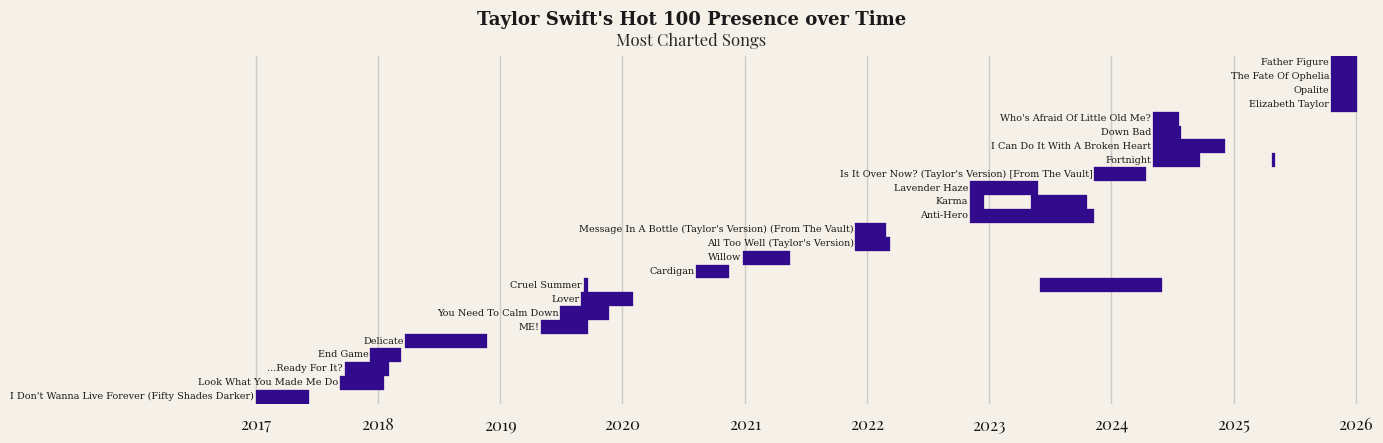

In [409]:
# timeline strip function 

def plot_timeline_strip(artist_df, artist_name, colors, n=25, figsize=(14, None)):
    df = artist_df.copy()
    df["chart_date"] = pd.to_datetime(df["chart_date"])

    df = df[df["rank"].notna()]

    top_n_titles = (
        df.groupby("title")["chart_date"]
        .count()
        .nlargest(n)
        .index
    )
    df = df[df["title"].isin(top_n_titles)]

    song_order = (
        df.groupby("title")["chart_date"]
        .min()
        .sort_values()
        .index.tolist()
    )

    n_songs = len(song_order)
    strip_height = 0.3
    gap = 0
    row_height = strip_height + gap

    fig_height = figsize[1] or max(4, n_songs * row_height * 0.6)
    fig, ax = plt.subplots(figsize=(figsize[0], fig_height))
    fig.patch.set_facecolor("#f5f0e8")
    ax.set_facecolor("#f5f0e8")

    date_min = df["chart_date"].min()
    date_max = df["chart_date"].max()

    for i, title in enumerate(song_order):
        song = df[df["title"] == title].sort_values("chart_date")
        y = i * row_height
        x_start_1 = mdates.date2num(song.iloc[0]["chart_date"])

        for _, row in song.iterrows():
            x_start = mdates.date2num(row["chart_date"])
            x_end   = mdates.date2num(row["chart_date"] + pd.Timedelta(weeks=1))

            rect = plt.Rectangle(
                (x_start, y),
                x_end - x_start,
                strip_height,
                color=colors[0],
                linewidth=0.2,
            )
            ax.add_patch(rect)

        ax.text(
            x_start_1-5,
            y + strip_height / 2,
            title,
            ha="right", va="center",
            fontsize=7, color="#1a1a1a",
            fontfamily="serif",
        )

    ax.set_xlim(
        mdates.date2num(date_min) - 60,
        mdates.date2num(date_max) + 14
    )
    ax.set_ylim(-gap, n_songs * row_height)
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.spines[:].set_visible(False)
    ax.yaxis.set_visible(False)
    ax.tick_params(colors="#1a1a1a", labelsize=12)

    fig.suptitle(
        f"{artist_name}'s Hot 100 Presence over Time",
        fontsize=13, fontweight="bold",
        color="#1a1a1a",
        fontfamily="serif",
    )
    fig.text(0.5, 0.90, f"Most Charted Songs",
            ha='center', fontsize=12)

    plt.tight_layout()
    return fig


fig = plot_timeline_strip(artist_df, artist, color1)
plt.show()

In [410]:
# heatmap function 

def plot_decay_heatmap(artist_df, artist_name, colors, sort='rise_rate', n=20):
    df = artist_df.copy()

    top_n_titles = (
        df.groupby("title")[sort]
        .max()
        .nlargest(n)
        .index
    )
    df = df[df["title"].isin(top_n_titles)]

    df = df.sort_values(["title", 'chart_date'])
    df["week_num"] = df.groupby("title").cumcount() + 1

    # pivot to matrix: rows = songs, cols = week number, values = rank
    matrix = df.pivot(index="title", columns="week_num", values="rank")

    # sort songs by max rise/decay rate
    rise_order = (
    df.groupby("title")[sort]
    .max()
    .sort_values(ascending=False)
    .index
)
    matrix = matrix.loc[rise_order]

    fig = go.Figure(go.Heatmap(
        z=matrix.values,
        x=matrix.columns.tolist(),
        y=matrix.index.tolist(),
        colorscale=[
            [0.0,  colors[1]],
            [1.0,  colors[2]], 
        ],
        reversescale=False,
        zmin=1,
        zmax=100,
        colorbar=dict(
            title=dict(text="Chart Rank", font=dict(size=11)),
            tickvals=[1, 25, 50, 75, 100],
            ticktext=["1", "25", "50", "75", "100"],
            tickfont=dict(size=10),
            thickness=12,
            len=0.6,
        ),
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Week %{x}<br>"
            "Rank #%{z}<extra></extra>"
        ),
        xgap=1,
        ygap=1,
    ))

    fig.update_layout(
        title=dict(
            text=f"<b>{artist_name}'s Chart Position Heatmap</b>",
            font=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
        ),
        plot_bgcolor="#f5f0e8",
        paper_bgcolor="#f5f0e8",
        font=dict(family="Playfair Display, serif", color="#1a1a1a"),
        xaxis=dict(
            title="<b>Weeks</b>",
            gridcolor="rgba(0,0,0,0)",
            linecolor="#d8d2c6",
        ),
        yaxis=dict(
            gridcolor="rgba(0,0,0,0)",
            linecolor="#d8d2c6",
            autorange="reversed", 
            tickfont=dict(size=12),
        ),
        margin=dict(t=60, r=20, b=60, l=180),
        height=max(400, n * 28),
    )

    return fig


fig = plot_decay_heatmap(heatmap_df, "Taylor Swift", color1, "rise_rate", n=20)
fig.show()

In [411]:
# violin plot 

def stats(data):
    return {
        'median': np.percentile(data, 50),
        'mean':   np.mean(data),
        'q1':     np.percentile(data, 25),
        'q3':     np.percentile(data, 75),
        'min':    np.min(data),
        'max':    np.max(data),
    }

def plot_violin(artist_df, artist_name, colors):
    df = artist_df.copy()

    decay_stats = stats(df['decay_rate'].dropna())
    rise_stats  = stats(df['rise_rate'].dropna())

    fig = go.Figure()

    fig.add_trace(go.Violin(
        x=df['rise_rate'],
        y=[''] * len(df),
        name='Rise Rate',
        side='positive',
        orientation='h',
        line_color=colors[0],
        fillcolor=colors[3],
        meanline=dict(visible=True, color=colors[0], width=2),
        showlegend=True,
        hoveron='kde'
    ))

    fig.add_trace(go.Violin(
        x=df['decay_rate'],
        y=[''] * len(df),
        name='Decay Rate',
        side='negative',
        orientation='h',
        line_color=colors[1],
        fillcolor=colors[4],
        meanline=dict(visible=True, color=colors[1], width=2),
        showlegend=True,
        hoveron='kde'
    ))

    fig.update_traces(points=False)

    for s, color, label in [
        (decay_stats, colors[1], 'Decay Rate'),
        (rise_stats,  colors[0], 'Rise Rate'),
    ]:
        fig.add_trace(go.Scatter(
            x=[s['mean']],
            y=[''],
            mode='markers',
            marker=dict(size=0, color=color, opacity=0),
            name=label,
            showlegend=False,
            hovertemplate=(
                f"<b>{label}</b><br>"
                f"Median: {s['median']:.1f}<br>"
                f"Mean: {s['mean']:.1f}<br>"
                f"Q1 – Q3: {s['q1']:.1f} – {s['q3']:.1f}<br>"
                f"Range: {s['min']:.1f} – {s['max']:.1f}"
                "<extra></extra>"
            ),
        ))



    fig.update_layout(
        violingap=0,
        violinmode='overlay',
        width=900,
        height=400,
        title=dict(
            text=f"<b>{artist_name}'s Rise and Decay Rate Distribution</b>",
            font=dict(family="Playfair Display, serif", size=18, color="#1a1a1a"),
        ),
        plot_bgcolor="#f5f0e8",
        paper_bgcolor="#f5f0e8",
        font=dict(family="Playfair Display, serif", color="#1a1a1a"),
        xaxis=dict(
            title="Average Position Changes per Week",
            gridcolor="#d8d2c6",
            linecolor="#d8d2c6",
            zerolinecolor="#d8d2c6",
        ),
        yaxis=dict(
            title='Density',
            range=[-0.5, 0.5],
        ),
        legend=dict(
            orientation="v",
            xanchor="right",
            yanchor="top",
            font=dict(size=11),
            bgcolor="rgba(0,0,0,0)",
            borderwidth=0,
            itemclick=False,
        ),
        margin=dict(t=60, r=20, b=60, l=20),
        hoverlabel=dict(
            bgcolor="#1a1a1a",
            bordercolor="#1a1a1a",
            font=dict(
                family="Source Sans 3, sans-serif",
                size=11,
                color="#f5f0e8",
            ),
),
    )

    return fig


fig = plot_violin(violin_df, "Taylor Swift", color1)
fig.show()

In [412]:
# function to do all for a specific artist 

def make_artist_viz(artist_name, file_tag, sort, colors):

    # import data
    df = pd.read_csv('../data/filled_hot100_history.csv', low_memory=False)

    # explode artists
    df['artist_list'] = df['artist_list'].apply(ast.literal_eval)
    df = df.explode('artist_list')

    # filter to specific artist
    artist = artist_name
    mask = (df['artist_list']==artist)
    artist_df = df.loc[mask]

    # merge with viral or decay to get song rates 
    if sort == 'rise_rate':
        heatmap_df = artist_df.merge(rise_artist_df, on=['title','artist_list'], how='inner')
        heatmap_df = heatmap_df.sort_values('rise_rate', ascending=False)
    if sort == 'decay_rate':
        heatmap_df = artist_df.merge(decay_artist_df, on=['title','artist_list'], how='inner')
        heatmap_df = heatmap_df.sort_values('decay_rate', ascending=False)

    # get both rise and decay for violin plot 
    both_df = decay_df.merge(rise_df, on=['artist','title', 'total_weeks','peak_rank','debut_rank','peak_week'], how='outer')
    both_df['artist_list'] = both_df['artist_list_x']
    both_df.drop(columns=['artist_list_x','artist_list_y'], inplace=True)
    both_df = both_df.explode('artist_list')
    violin_df = both_df.loc[both_df['artist_list']==artist]

    # timeline strip plot
    fig = plot_timeline_strip(artist_df, artist, colors)
    fig.savefig(f"../charts/timeline_{file_tag}.svg", format="svg", bbox_inches="tight")

    # heatmap 
    fig = plot_decay_heatmap(heatmap_df, artist, colors, sort, n=20)
    fig.write_html(f"../charts/heatmap_{file_tag}.html", include_plotlyjs="cdn", full_html=False)

    # violin plot
    fig = plot_violin(violin_df, artist_name, colors)
    fig.write_html(f"../charts/violin_{file_tag}.html", include_plotlyjs="cdn", full_html=False)


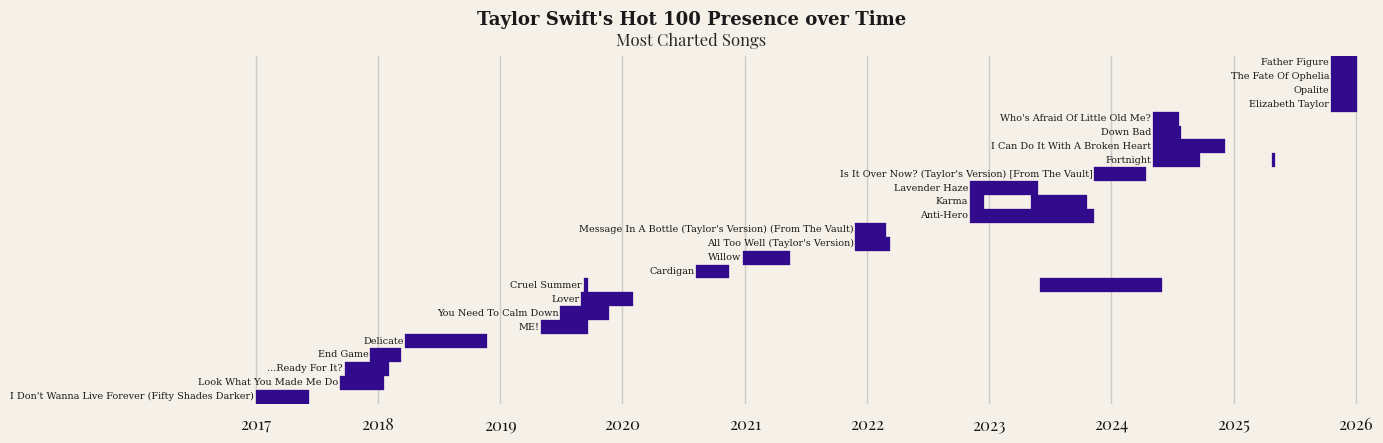

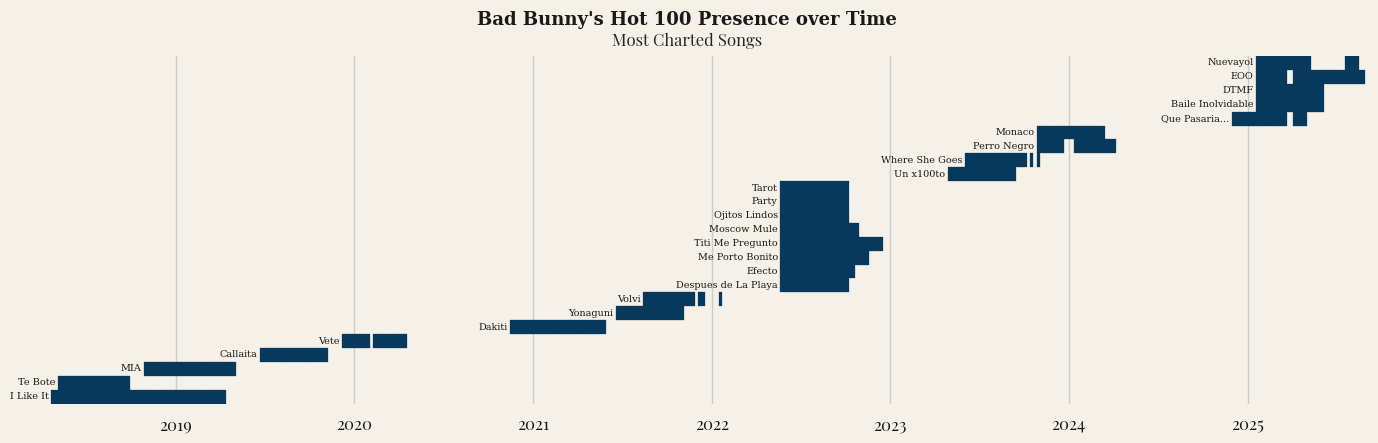

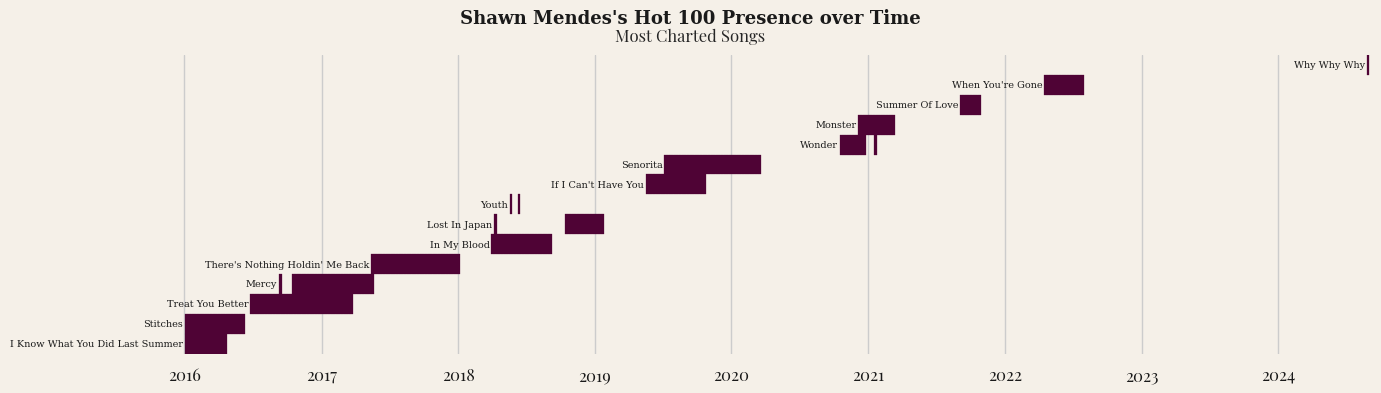

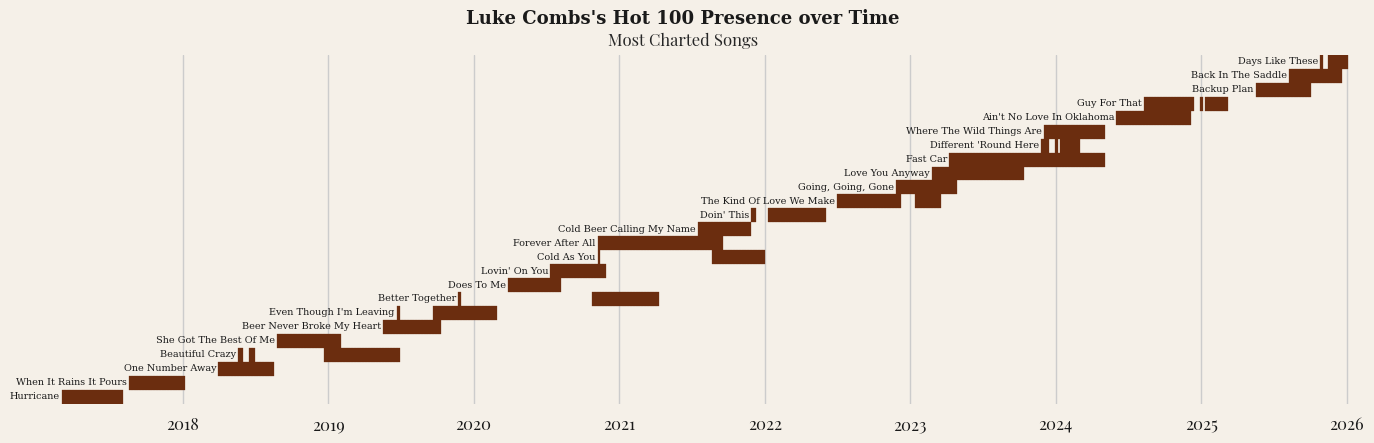

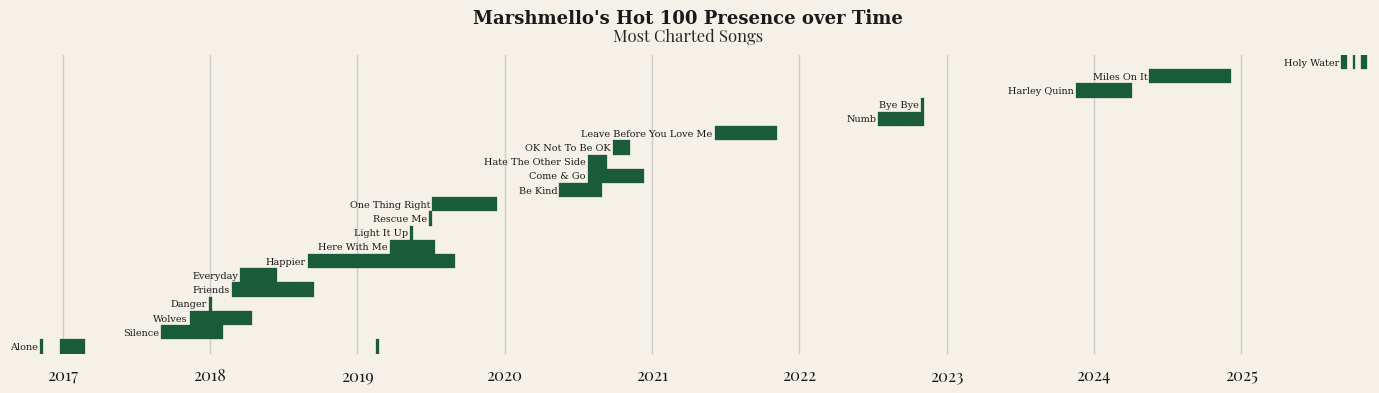

In [419]:
make_artist_viz('Taylor Swift', 'taylor_swift', 'rise_rate', color1)
make_artist_viz('Bad Bunny', 'bad_bunny', 'rise_rate', color2)
make_artist_viz('Shawn Mendes', 'shawn_mendes', 'decay_rate', color3)
make_artist_viz('Luke Combs', 'luke_combs', 'decay_rate', color4)
make_artist_viz('Marshmello', 'marshmello', 'rise_rate', color5)